<a href="https://colab.research.google.com/github/gvp2ms/A01-data-wrangling/blob/main/notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Tiffany Kim

**Date:** 09/02/2026

In [228]:
# Your Phase 1 solution to the problem goes here.
#Question 1.1
import pandas as pd

airbnb = pd.read_csv('airbnb_hw.csv')

print(airbnb['Price'].dtype)
print(airbnb['Price'].describe())
print()

#Find how many values have commas
comma_total = airbnb['Price'].str.contains(',').sum()
print("There are this many rows with commas:", comma_total)
print("These values (prices that exceed 999) will end up as null values because they contain commas so they aren't registered as valid numbers.")
print()
#Find which rows they're on
with_commas = df[airbnb['Price'].str.contains(',', na=False)]
print(with_commas)
print()

#Replace each value that contains a comma with a commaless one
airbnb['Price_clean'] = pd.to_numeric(airbnb['Price'].str.replace(',', '', regex=False), errors = 'coerce')
#Print information about new "cleaned" Price column
print(airbnb['Price_clean'].dtype)
print(airbnb['Price_clean'].describe())
print()
#Print first three values that had commas to ensure proper removal of comma
print("Example cleaning:")
print(airbnb['Price_clean'].iloc[101])
print(airbnb['Price_clean'].iloc[263])
print(airbnb['Price_clean'].iloc[764])
print()
#Print any missing values in column
print("Missing values after cleaning: ", airbnb['Price_clean'].isna().sum())


object
count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object

There are this many rows with commas: 181
These values (prices that exceed 999) will end up as null values because they contain commas so they aren't registered as valid numbers.

       Price
101    1,990
263    1,000
764    1,200
1272   1,000
1275   5,000
...      ...
28951  3,390
28952  1,356
28953  2,599
28985  2,000
30281  2,000

[181 rows x 1 columns]

int64
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price_clean, dtype: float64

Example cleaning:
1990
1000
1200

Missing values after cleaning:  0


In [174]:
#Question 1.2
import pandas as pd

police = pd.read_csv('mn_police_use_of_force.csv')
#Tells how many total rows are in the data
print("There are",len(police), "total rows.")
#Shows the number of rows that have a non-null value for the 'subject_injury' column
print()
print(police['subject_injury'].describe())
print()
#Shows how many null values there are for 'subject_injury'
print("The number of rows with null data is:", police['subject_injury'].isnull().sum(),".")
print("The proportion of values that are missing is:", police['subject_injury'].isna().mean(),".")
print("This is a concern because majority of these cases have unknown injury reports, \nmeaning it is hard to confirm how often people were actually injured in police encounters.")
print()

#Replaces all null values in 'subject_injury' with "Unknown" and stores it in a "cleaned" copy
police_clean = police.copy()
police_clean['subject_injury'] = police_clean['subject_injury'].fillna('Unknown')
#Confirms that there are no null values in the cleaned version
print("Number of null values:", police_clean['subject_injury'].isna().sum())
print()

#Cross-tabulation of subject_injury and force_type
print("Yes, there are patterns. Most of the 'unknown' cases happened for bodily force, chemical irritants, and tasers. These are all harder to document injury compared to actual weapons such as firearms and projectiles, making it hard to confirm how many people were actually hurt by the police.")
pd.crosstab(police_clean['subject_injury'], police_clean['force_type'])




There are 12925 total rows.

count     3077
unique       2
top        Yes
freq      1631
Name: subject_injury, dtype: object

The number of rows with null data is: 9848 .
The proportion of values that are missing is: 0.7619342359767892 .
This is a concern because majority of these cases have unknown injury reports, 
meaning it is hard to confirm how often people were actually injured in police encounters.

Number of null values: 0

Yes, there are patterns. Most of the 'unknown' cases happened for bodily force, chemical irritants, and tasers. These are all harder to document injury compared to actual weapons such as firearms and projectiles, making it hard to confirm how many people were actually hurt by the police.


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Unknown,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


(7117, 23)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')

(7117, 21)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order'],
      dtype='object')


Most attacks in a year: 143
Year: 2015.0

Least attacks in a year: 16
Year: 1945.0

Average attacks per year: 64.14942528735632

Year_clean
2015.0    143
2017.0    141
2016.0    133
2011.0    128
2014.0    126
         ... 
1977.0     26
1978.0     26
1979.0     25
1940.0     24
1945.0     16
Name: count, Length: 87, dtype: int64
According to the data, attacks have generally been increasing o

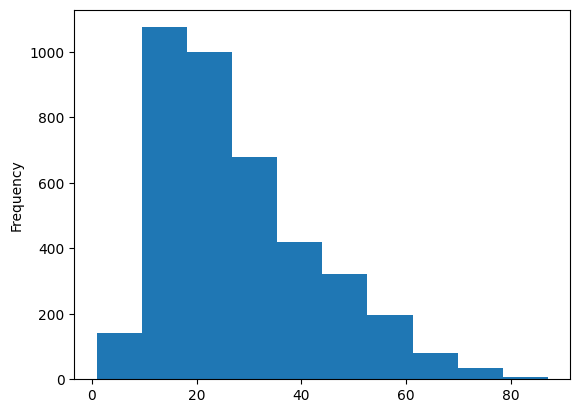

In [223]:
import pandas as pd
shark = pd.read_excel('GSAF5.xls')
#Number of rows and columns in the data
print(shark.shape)
#Lists out all the columns in the data, including the Unnamed columns
print(shark.columns)
print()

#Makes a copy of the data and removes all columns that have "Unnamed"
shark_clean = shark.copy()
shark_clean = shark_clean.drop(columns=shark_clean.filter(like="Unnamed").columns)
#Reprints the number of rows and columns and column names, confirming "Unnamed" columns were removed
print(shark_clean.shape)
print(shark_clean.columns)
print()

#Removes all null years
shark['Year_clean'] = shark['Year'].dropna()
print()
#Removes all years before 1940
shark_1940 = shark[shark['Year_clean'] >= 1940]
#Counts the number of attacks per year
attacks_by_year = shark_1940.value_counts('Year_clean')
#Prints the maximum number of attacks and which year it occured
print("Most attacks in a year:" ,attacks_by_year.max())
print("Year:", attacks_by_year.idxmax())
print()
#Prints the minimum number of attacks and which year it occured
print("Least attacks in a year:" ,attacks_by_year.min())
print("Year:", attacks_by_year.idxmin())
print()
#Prints the average attacks per year
print("Average attacks per year:" ,attacks_by_year.mean())
print()
print(attacks_by_year)
#attacks_by_year.plot()
print("According to the data, attacks have generally been increasing over time. However, there was a significant drop in attacks since the mid 2010s.")
print()

#Removes all null or "?" ages
shark['Ages_clean'] = shark['Age'].replace('?',pd.NA)
ages = pd.to_numeric(shark['Ages_clean'].dropna(), errors = 'coerce')
#Plots ages as a histogram
ages.plot(kind='hist')
print()

#Number of total reports
print("There were", len(shark), "reports total.")
#Number of reports for "M" sex
gender_male = shark['Sex'].str.contains('M').sum()
print("Of these,", gender_male, "were male.")
#Proportion of "M"/total
print("So, the proportion of victims that are male is:", gender_male/len(shark),".")
print()

#Uses if/else loop to keep the "Provoked" and "Unprovoked" types and keeping all else as "Unknown"
shark['Type_clean'] = shark['Type'].apply(lambda x: x if x in ["Provoked", "Unprovoked"] else "Unknown")
#Finding the proportion of "Unprovoked" attacks
prop_unprovoked = (shark["Type"] == "Unprovoked").mean()
print("The proportion of unknown attacks is:", prop_unprovoked)



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]